In [128]:
from itertools import count

import numpy as np
from scipy.interpolate import make_splprep, BSpline
import matplotlib.pyplot as plt
from matplotlib.image import imread
from skimage import measure

In [75]:
img = imread("C:/Documents/RGB Color Router/Kim2inner.png")

In [79]:
img1 = np.roll(img, 32, axis=(0, 1))
img1[0] = 0
img1[-1] = 0
img1[:, 0] = 0
img1[:, -1] = 0

In [90]:
contours = measure.find_contours(img1)
print(len(contours))

12


(2027,) (77,)


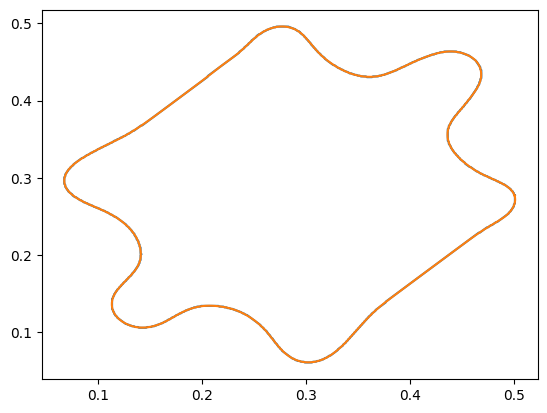

In [145]:
countour_index = 1

countour = (contours[countour_index] / img.shape[0]).T
plt.plot(*countour)

spl, u = make_splprep(countour, k=3, s=1e-4, bc_type='periodic')
print(u.shape, spl.t.shape)

u_samples = np.linspace(0, 1, 500)
plt.plot(*spl(u_samples))

plt.show()

In [150]:
x, y = spl(np.linspace(0, 1, 50))
y = 1 - y
x, y = np.round(x, 5), np.round(y, 5)

latex = f'\\draw ({x[0]}, {y[0]}) to[closed, curve through = {{'
for xi, yi in zip(x[1:-1], y[1:-1]):
    latex += f'({xi}, {yi}) '
latex += f'}}] ({x[-1]},{y[-1]});'

print(latex)

\draw (0.50015, 0.72289) to[closed, curve through = {(0.49076, 0.75021) (0.46749, 0.76995) (0.44515, 0.79166) (0.42293, 0.81387) (0.40069, 0.8361) (0.37868, 0.85838) (0.35906, 0.88168) (0.34266, 0.90627) (0.32358, 0.92956) (0.29646, 0.93814) (0.27397, 0.91896) (0.25859, 0.89399) (0.23639, 0.8734) (0.20807, 0.86552) (0.1803, 0.87454) (0.15569, 0.8911) (0.12759, 0.8891) (0.11352, 0.86383) (0.12425, 0.83679) (0.1394, 0.81165) (0.13893, 0.78277) (0.12404, 0.75735) (0.10016, 0.73932) (0.07596, 0.72249) (0.06933, 0.69521) (0.08819, 0.67214) (0.11248, 0.65491) (0.13656, 0.63717) (0.15912, 0.61585) (0.18135, 0.59357) (0.20332, 0.5713) (0.22503, 0.54885) (0.24531, 0.52583) (0.26738, 0.50615) (0.29449, 0.51223) (0.31115, 0.53686) (0.33209, 0.5585) (0.35897, 0.56931) (0.38653, 0.5607) (0.41146, 0.54544) (0.43921, 0.53651) (0.46424, 0.55067) (0.4659, 0.57944) (0.4524, 0.6054) (0.43809, 0.63086) (0.43893, 0.6602) (0.45587, 0.68444) (0.4799, 0.70202) }] (0.50015,0.72289);


In [154]:
for countour_index in range(len(contours)):
    if countour_index == 1:
        n_samples = 50
    else:
        n_samples = 20

    countour = (contours[countour_index] / img.shape[0]).T
    spl, u = make_splprep(countour, k=3, s=1e-4, bc_type='periodic')

    x, y = spl(np.linspace(0, 1, n_samples))
    y = 1 - y
    x, y = np.round(x, 5), np.round(y, 5)

    latex = f'\\filldraw ({x[0]}, {y[0]}) to[closed, curve through = {{'
    for xi, yi in zip(x[1:-1], y[1:-1]):
        latex += f'({xi}, {yi}) '
    latex += f'}}] ({x[-1]},{y[-1]});'

    print(latex)

\filldraw (0.1688, 0.48269) to[closed, curve through = {(0.16373, 0.50865) (0.14922, 0.53203) (0.12965, 0.55199) (0.10668, 0.56663) (0.08013, 0.57325) (0.0527, 0.56964) (0.03001, 0.55527) (0.01389, 0.53346) (0.00592, 0.5073) (0.00907, 0.48095) (0.02041, 0.45627) (0.03469, 0.43344) (0.05532, 0.41546) (0.07983, 0.40339) (0.1064, 0.40223) (0.13154, 0.41251) (0.15082, 0.43209) (0.16283, 0.45643) }] (0.1688,0.48269);
\filldraw (0.50015, 0.72289) to[closed, curve through = {(0.49076, 0.75021) (0.46749, 0.76995) (0.44515, 0.79166) (0.42293, 0.81387) (0.40069, 0.8361) (0.37868, 0.85838) (0.35906, 0.88168) (0.34266, 0.90627) (0.32358, 0.92956) (0.29646, 0.93814) (0.27397, 0.91896) (0.25859, 0.89399) (0.23639, 0.8734) (0.20807, 0.86552) (0.1803, 0.87454) (0.15569, 0.8911) (0.12759, 0.8891) (0.11352, 0.86383) (0.12425, 0.83679) (0.1394, 0.81165) (0.13893, 0.78277) (0.12404, 0.75735) (0.10016, 0.73932) (0.07596, 0.72249) (0.06933, 0.69521) (0.08819, 0.67214) (0.11248, 0.65491) (0.13656, 0.63717) (